In [ ]:
## Research Paper Theory
-  Author said ki new car ki shortage and badhti demand ki wjh se used car ka market bht complex ho gya h aur hme isi complexity
   ko duur krna h.
- Problem Statement: Research ka main focus "Information Asymmetry" ko khatam karna hai. Authors explain karte hain ki aksar
                   buyers ko car ki actual condition aur fair price ka pata nahi hota (jise economics mein 'Lemon Market' 
                 kehtehain).
       
- Key Findings: Determinants of Price:: Research se pata chalta hai ki saare factors equal nahi hote. Price predict karne mein 
                                       main role in factors ka hai:
1 Maximum Power: 
2 Vehicle Age & Kilometers Driven 
3 Engine & Brand

In [ ]:
##Literature Review
1.Car Age ka Impact:: Jaise-jaise car purani hoti hai, uski price decrease hoti hai (depreciation effect).
2.Mileage Effect:: High mileage wali cars ki resale value kam hoti hai, kyunki unki condition weak hoti hai.
3.Brand Value:: Popular brands (Maruti, Hyundai) ki resale value zyada stable hoti hai due to trust & service.
4.Fuel Type & Transmission:: Diesel, petrol aur automatic/manual transmission ka price par significant impact hota hai.

In [ ]:
## HYPOTHESIS
1.Depreciation Curve: Car ki value ekdm nhi girti first 3 to 5 year ke bd sbse jyada drop hoti h and the slowly.
2.Festive season m sales jyada hoti h.
3.Premium brand purani hone ke bd bhi market mai acchi value hold krte h
4.Mileage-Age Correlation.

In [2]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
# Set style for publication-ready plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2") 
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [4]:
# Display all columns
pd.set_option('display.max_columns', None)

In [5]:
# Cell 2: Load data
df = pd.read_csv('used_cars_mock.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head(15)

Dataset shape: (10000, 10)

First 5 rows:


,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price
0,1,Honda,Model A,2020,50757.0,Petrol,Manual,7,30,999999
1,2,Fiat,Model B,2030,NaN,Hybrid,Automatic,1,1,19076
2,3,Audi,Model C,2025,-500.0,Petrol,Automatic,12,1,29629
3,4,VW,Model B,2023,10661.0,XYZ,Automatic,10,20,18132
4,5,Dacia,Model C,2015,126515.0,Petrol,Manual,7,30,0
5,6,VW,Model C,2015,121974.0,Petrol,Manual,12,1,500
6,7,BMW,Model B,2005,247373.0,Petrol,Automatic,4,10,500
7,8,Ford,Model B,2025,3210.0,Hybrid,Automatic,11,1,21820
8,9,Mercedes,Model A,2023,34565.0,Diesel,Automatic,11,1,21380
9,10,BMW,Model A,2025,13173.0,Petrol,Automatic,8,30,33616


## Phase 1: Data Audit (What's Wrong With This Picture?)

In [40]:

# Cell 3: First-pass inspection
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   car_id        10000 non-null  int64  
 1   brand         10000 non-null  object 
 2   model         10000 non-null  object 
 3   year          10000 non-null  int64  
 4   mileage       9694 non-null   float64
 5   fuel_type     10000 non-null  object 
 6   transmission  10000 non-null  object 
 7   sale_month    10000 non-null  int64  
 8   zip_prefix    10000 non-null  int64  
 9   price         10000 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 781.4+ KB


**Discussion:** Notice `mileage` has 9700 non-null (300 missing). `year` has 2030 (impossible). `price` has 0 and 999999. `fuel_type` has 'XYZ'. This is intentional – good EDA starts with finding broken data.

In [10]:
# Cell 4: Summary statistics – look for impossibilities
df.describe()

,car_id,year,mileage,sale_month,zip_prefix,price
count,10000.00000,10000.000000,9694.000000,10000.000000,10000.00000,10000.000000
mean,5000.50000,2019.804700,62036.526718,6.738100,15.42200,15278.148600
std,2886.89568,6.324884,71546.816912,3.581451,11.57261,13725.370724
min,1.00000,2000.000000,-500.000000,1.000000,1.00000,0.000000
25%,2500.75000,2018.000000,7771.000000,4.000000,1.00000,6761.500000
50%,5000.50000,2022.000000,35781.500000,7.000000,20.00000,15852.000000
75%,7500.25000,2025.000000,87767.500000,10.000000,30.00000,23125.000000
max,10000.00000,2030.000000,250000.000000,12.000000,30.00000,999999.000000


**What students should notice:**
- `price` min = 0, max = 999,999 (absurd)
- `year` max = 2030 (future car)
- `mileage` min = -500 (impossible)


In [11]:
# Cell 5: Systematic data quality check
print("=== DATA QUALITY REPORT ===\n")

=== DATA QUALITY REPORT ===



In [12]:
# Check for impossible values
print(f"1. Cars with year > {pd.Timestamp.now().year}: {len(df[df['year'] > 2025])}")
print(f"2. Cars with price <= 0: {len(df[df['price'] <= 0])}")
print(f"3. Cars with negative mileage: {len(df[df['mileage'] < 0])}")
print(f"4. Invalid fuel types: {df['fuel_type'].unique()}")


1. Cars with year > 2026: 1
2. Cars with price <= 0: 1
3. Cars with negative mileage: 1
4. Invalid fuel types: ['Petrol' 'Hybrid' 'XYZ' 'Diesel']


In [13]:
# Check for duplicates
print(f"\n5. Duplicate car_ids: {df['car_id'].duplicated().sum()}")


5. Duplicate car_ids: 0


In [14]:
# Missing values
print(f"\n6. Missing values:\n{df.isnull().sum()}")


6. Missing values:
car_id            0
brand             0
model             0
year              0
mileage         306
fuel_type         0
transmission      0
sale_month        0
zip_prefix        0
price             0
dtype: int64


In [15]:
# Cell 6: Fix the data issues (document every decision!)
df_clean = df.copy()

In [16]:
# Fix 1: Remove future cars (keep only up to current year)
df_clean = df_clean[df_clean['year'] <= 2025]

In [17]:
# Fix 2: Remove impossible prices (0 or > 200,000)
df_clean = df_clean[(df_clean['price'] > 500) & (df_clean['price'] < 200000)]


In [18]:
# Fix 3: Remove negative mileage
df_clean = df_clean[df_clean['mileage'] >= 0]


In [19]:
# Fix 4: Fix invalid fuel types (most likely 'XYZ' is Petrol typo)
df_clean.loc[df_clean['fuel_type'] == 'XYZ', 'fuel_type'] = 'Petrol'

In [21]:
# Fix 5: Handle missing mileage – fill with median by age group
df_clean['age'] = 2025 - df_clean['year']
median_mileage_by_age = df_clean.groupby('age')['mileage'].transform('median')
df_clean['mileage'].fillna(median_mileage_by_age, inplace=True)

print(f"Rows removed: {len(df) - len(df_clean)} ({100*(1-len(df_clean)/len(df)):.1f}%)")
print(f"Clean dataset shape: {df_clean.shape}")

Rows removed: 1171 (11.7%)
Clean dataset shape: (8829, 11)


## Phase 2: Univariate Analysis – Know Each Variable Alone

# Price

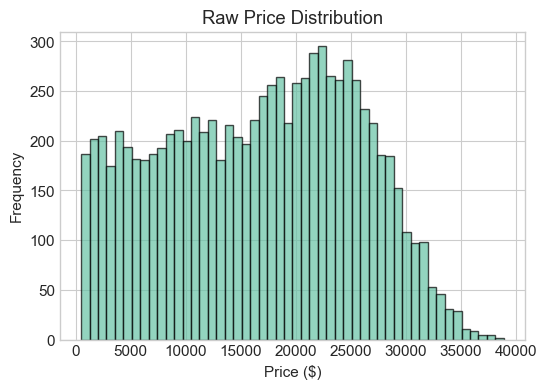

In [28]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4))

axes.hist(df_clean['price'], bins=50, edgecolor='black', alpha=0.7)
axes.set_title('Raw Price Distribution')
axes.set_xlabel('Price ($)')
axes.set_ylabel('Frequency')

plt.show()

In [ ]:
Right Skewness: Graph right side ki taraf(tail bana raha hai. Iska matlab hai ki jaise-jaise price badhti hai (30k+)
gaadiyon ki frequency kam hoti ja rahi hai.
## hm isme dekh skte h ki 2,000 se 10,000 ke beech ek chhota bump hai. Yeh purani gaadiyan ya budget cars ho sakti hain.
## 17,000 se 28,000 ke beech sabse bada cluster hai. Yeh market ka "sweet spot" hai jahan log sabse zyada gaadiyan kharidte 
    ya bechte hain

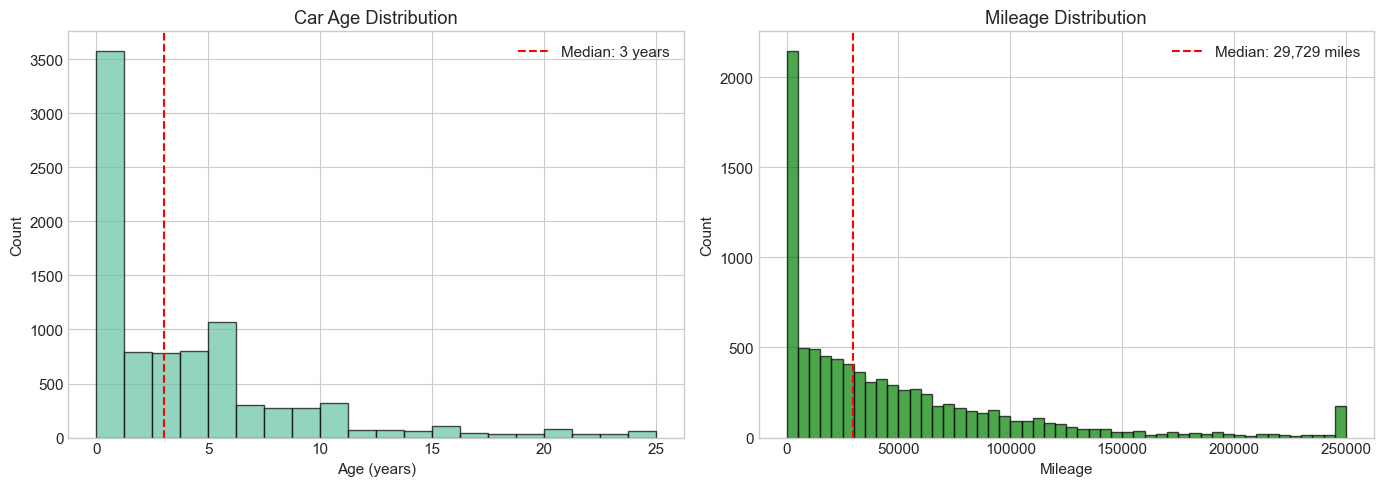

In [35]:
# Cell 8: Numeric features – Age and Mileage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Age distribution
axes[0].hist(df_clean['age'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Car Age Distribution')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].axvline(df_clean['age'].median(), color='red', linestyle='--', label=f"Median: {df_clean['age'].median():.0f} years")
axes[0].legend()

# Mileage distribution
axes[1].hist(df_clean['mileage'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Mileage Distribution')
axes[1].set_xlabel('Mileage')
axes[1].set_ylabel('Count')
axes[1].axvline(df_clean['mileage'].median(), color='red', linestyle='--', label=f"Median: {df_clean['mileage'].median():,.0f} miles")
axes[1].legend()

plt.tight_layout()
plt.show()

## DEPRICIATION LINK

In [ ]:
## Age:: 
- 0 to 3 years dekhne se pta chla ki dataset recent modal pr focused h
- 5 saal ke baad frequency kaafi gir jati hai. Yeh research papers ki us baat ko confirm karta hai ki gaadiyon ki price aur
  supply non-linearly girti hai jaise-jaise age badhti hai.
## Mileage::
- Zyadatar gaadiyan lagbhag 30,000 miles tak chali hui hain.
- First bin dekhne se pta chlta h ki low mileage car ki supply market m jyada h.
## DEPRICIATION LINK:: ye dono graph ki shape right skewed h jo ki price ke graph ke similar h to we connect the dot ki age and
                       mileage ke drop hone se price exponentially bdh jata h.

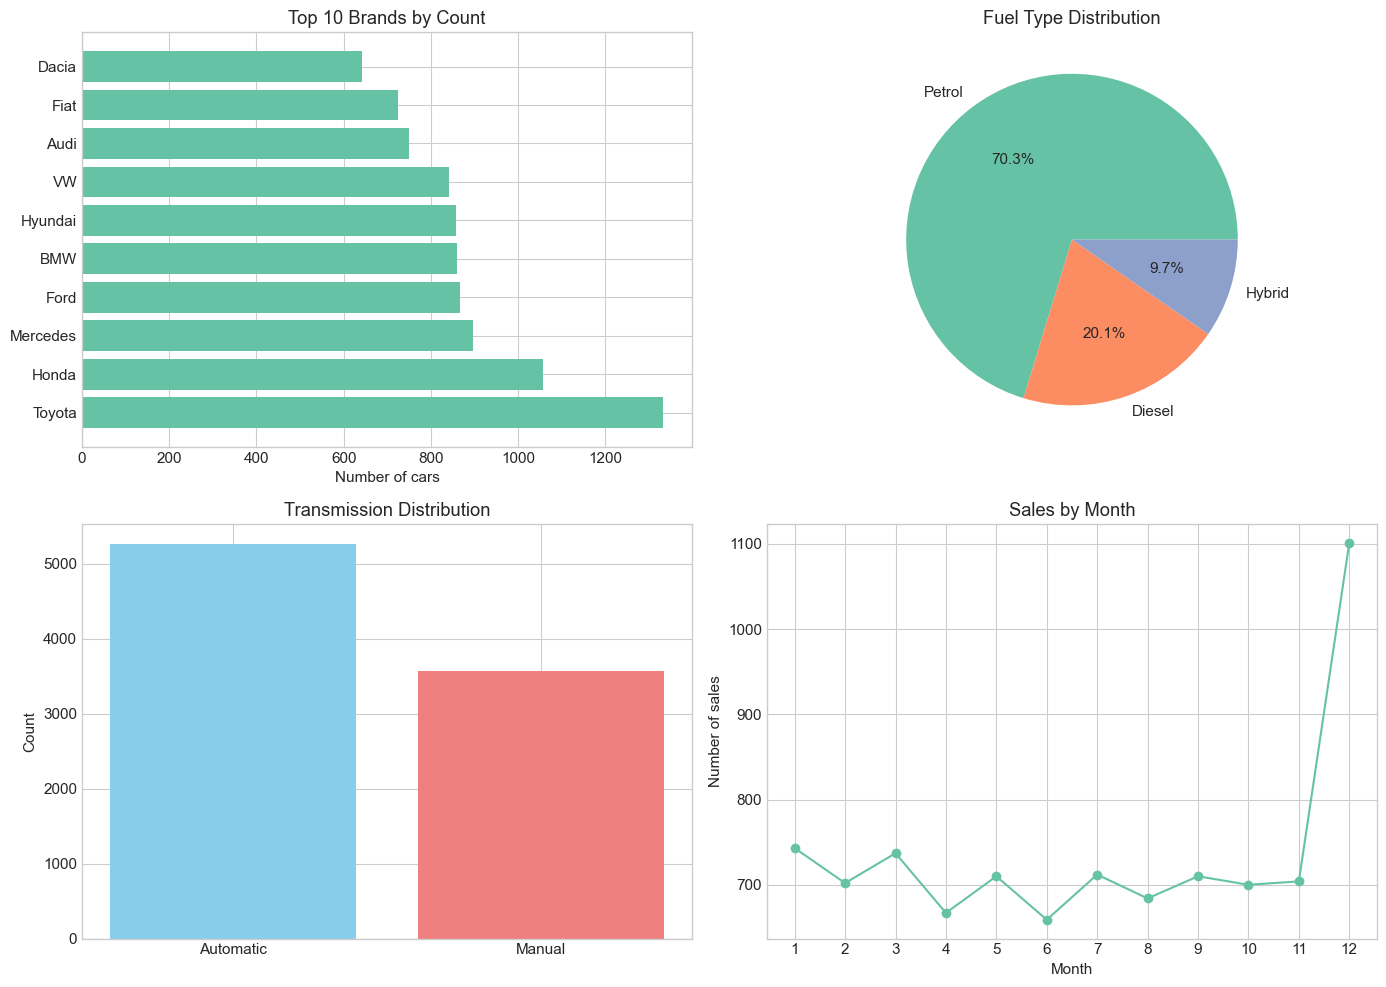

In [36]:
# Cell 9: Categorical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Brand frequency
brand_counts = df_clean['brand'].value_counts().head(10)
axes[0,0].barh(brand_counts.index, brand_counts.values)
axes[0,0].set_title('Top 10 Brands by Count')
axes[0,0].set_xlabel('Number of cars')

# Fuel type
fuel_counts = df_clean['fuel_type'].value_counts()
axes[0,1].pie(fuel_counts, labels=fuel_counts.index, autopct='%1.1f%%')
axes[0,1].set_title('Fuel Type Distribution')

# Transmission
trans_counts = df_clean['transmission'].value_counts()
axes[1,0].bar(trans_counts.index, trans_counts.values, color=['skyblue', 'lightcoral'])
axes[1,0].set_title('Transmission Distribution')
axes[1,0].set_ylabel('Count')

# Sale month
month_counts = df_clean['sale_month'].value_counts().sort_index()
axes[1,1].plot(month_counts.index, month_counts.values, marker='o')
axes[1,1].set_title('Sales by Month')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Number of sales')
axes[1,1].set_xticks(range(1,13))

plt.tight_layout()
plt.show()

In [ ]:
## month ek imp feature ho Skta Hai bcz at the end of year people sell old cars and buy new one.
PRO TIP==> #Toyota aur honda hmesha sell hone wali cars h to slow month pr inhi pr focus kre
PRO TIP==> #Low mileage and young cars ko promote kre bcz buyers inke liye premium dene kon taiyar rehte h
PRO TIP==> #har car ke sath documented service history aur inspection report de taki mechanical reliability ho

### Pattern 3: Brand hierarchy (OBVIOUS)

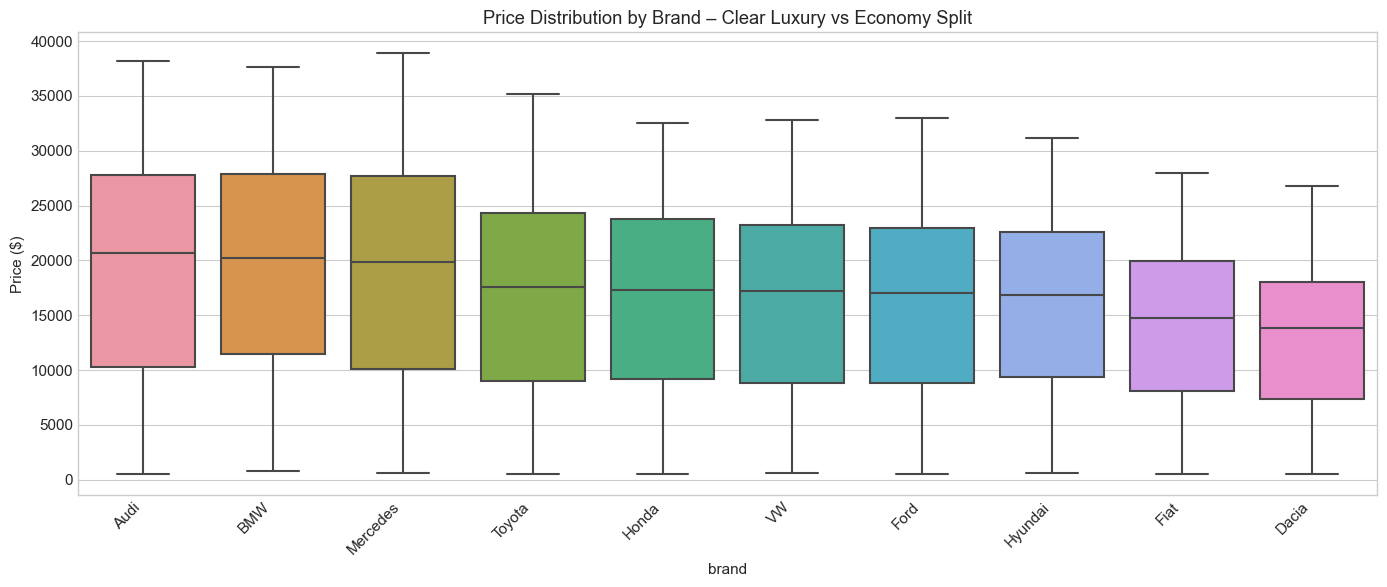


Annual depreciation rate by brand (more negative = faster depreciation):
brand
Honda      -0.158367
Audi       -0.154831
VW         -0.150641
Mercedes   -0.150269
Toyota     -0.147279
BMW        -0.147171
Hyundai    -0.146429
Fiat       -0.145795
Dacia      -0.145211
Ford       -0.144413
dtype: float64


In [41]:
# Cell 12: Price by Brand
fig, ax = plt.subplots(figsize=(14, 6))

# Order by median price
brand_order = df_clean.groupby('brand')['price'].median().sort_values(ascending=False).index
sns.boxplot(x='brand', y='price', data=df_clean, order=brand_order)

ax.set_title('Price Distribution by Brand – Clear Luxury vs Economy Split')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

# Calculate depreciation rate by brand (advanced)
brand_depreciation = df_clean.groupby('brand').apply(
    lambda x: np.polyfit(x['age'], np.log1p(x['price']), 1)[0]
).sort_values()
print("\nAnnual depreciation rate by brand (more negative = faster depreciation):")
print(brand_depreciation)

In [ ]:
## INSIGHT
Audi se Mercedes tk sbhi ki price 20k ke as pas h, toyota s hyundai tk sbhi ka medain ek h yani ye brands market m ek dusre ke
direct compitetor h.

### Pattern 5: Diesel penalty in urban areas (SUBTLE – Simpson's paradox example)

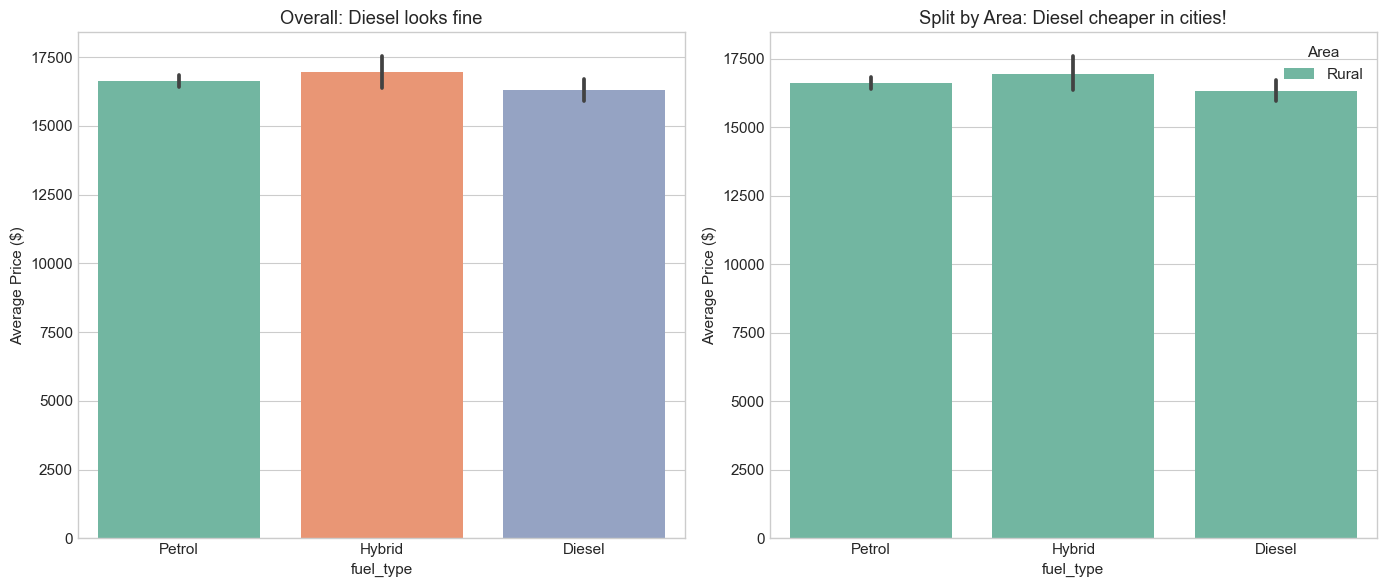

Urban: Diesel $nan vs Petrol $nan → Diesel penalty: $nan
Rural: Diesel $16,311 vs Petrol $16,623 → Diesel penalty: $312


In [45]:
# Cell 14: The hidden diesel penalty – only visible when splitting by area
df_clean['area_type'] = df_clean['zip_prefix'].apply(lambda x: 'Urban' if x == '01' else 'Rural')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Overall (misleading)
sns.barplot(x='fuel_type', y='price', data=df_clean, ax=axes[0], errorbar='ci')
axes[0].set_title('Overall: Diesel looks fine')
axes[0].set_ylabel('Average Price ($)')

# Split by area (reveals truth)
sns.barplot(x='fuel_type', y='price', hue='area_type', data=df_clean, ax=axes[1], errorbar='ci')
axes[1].set_title('Split by Area: Diesel cheaper in cities!')
axes[1].set_ylabel('Average Price ($)')
axes[1].legend(title='Area')

plt.tight_layout()
plt.show()

# Calculate the penalty
urban_diesel = df_clean[(df_clean['area_type'] == 'Urban') & (df_clean['fuel_type'] == 'Diesel')]['price'].mean()
urban_petrol = df_clean[(df_clean['area_type'] == 'Urban') & (df_clean['fuel_type'] == 'Petrol')]['price'].mean()
rural_diesel = df_clean[(df_clean['area_type'] == 'Rural') & (df_clean['fuel_type'] == 'Diesel')]['price'].mean()
rural_petrol = df_clean[(df_clean['area_type'] == 'Rural') & (df_clean['fuel_type'] == 'Petrol')]['price'].mean()

print(f"Urban: Diesel ${urban_diesel:,.0f} vs Petrol ${urban_petrol:,.0f} → Diesel penalty: ${urban_petrol - urban_diesel:,.0f}")
print(f"Rural: Diesel ${rural_diesel:,.0f} vs Petrol ${rural_petrol:,.0f} → Diesel {'premium' if rural_diesel > rural_petrol else 'penalty'}: ${abs(rural_diesel - rural_petrol):,.0f}")

**PATTERN 5 DISCOVERED:** This is a classic **Simpson's paradox**. 
1st graph se dekhte h ki petrol diesel ka same avg pr h lekin jb hm inhe urban and rular m devide krte h to , cities  m diesel kam use hota h bcz of ""EMISSION NORMS" and ""Diesel bans"".

### Pattern 6: Odometer rollback fraud (TRICKY – needs feature engineering)


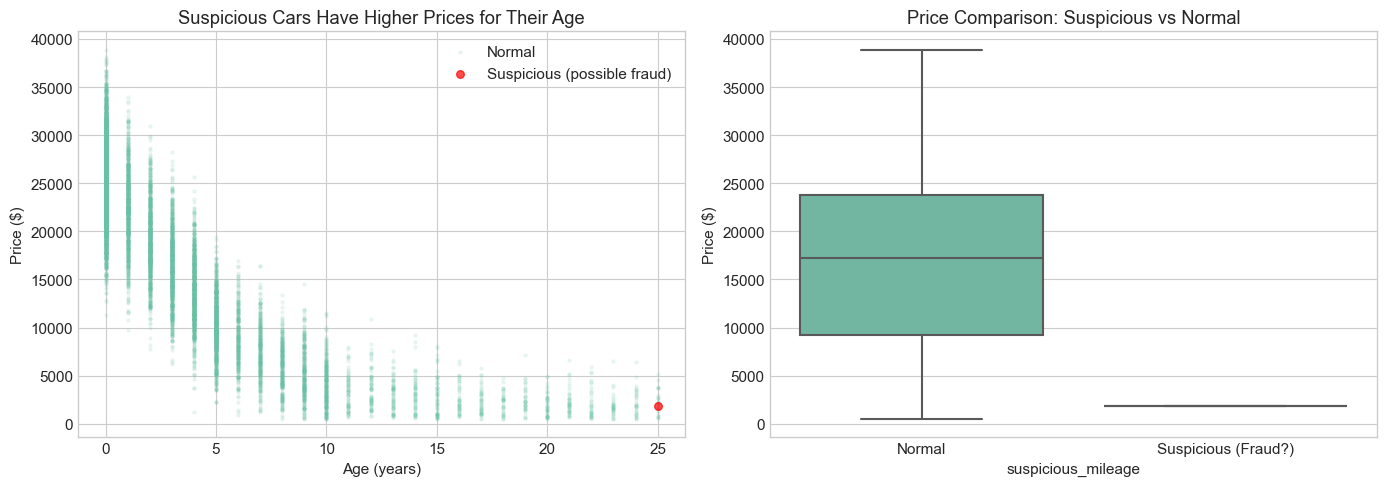

Suspicious cars detected: 1 (0.0%)
Average price – Normal: $16,595
Average price – Suspicious: $1,825
Price premium for suspicious cars: $-14,770


In [46]:
# Cell 15: Detect odometer fraud by calculating miles per year
df_clean['miles_per_year'] = df_clean['mileage'] / (df_clean['age'] + 0.1)  # +0.1 to avoid div/0

# Flag suspicious cars (old but very low mileage)
df_clean['suspicious_mileage'] = (df_clean['age'] > 10) & (df_clean['miles_per_year'] < 3000)

# Compare prices
fraud_cars = df_clean[df_clean['suspicious_mileage']]
normal_cars = df_clean[~df_clean['suspicious_mileage']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot highlighting fraud
axes[0].scatter(normal_cars['age'], normal_cars['price'], alpha=0.1, s=5, label='Normal')
axes[0].scatter(fraud_cars['age'], fraud_cars['price'], alpha=0.7, s=30, color='red', label='Suspicious (possible fraud)')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('Suspicious Cars Have Higher Prices for Their Age')
axes[0].legend()

# Boxplot comparison
sns.boxplot(x='suspicious_mileage', y='price', data=df_clean, ax=axes[1])
axes[1].set_xticklabels(['Normal', 'Suspicious (Fraud?)'])
axes[1].set_title('Price Comparison: Suspicious vs Normal')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

print(f"Suspicious cars detected: {len(fraud_cars)} ({100*len(fraud_cars)/len(df_clean):.1f}%)")
print(f"Average price – Normal: ${normal_cars['price'].mean():,.0f}")
print(f"Average price – Suspicious: ${fraud_cars['price'].mean():,.0f}")
print(f"Price premium for suspicious cars: ${fraud_cars['price'].mean() - normal_cars['price'].mean():,.0f}")

In [ ]:
## This is the Example of The Lemon theory :: RED DOT KA MTLB H PURANI CAR KO JYADA PRICE M SELL KR RHE H .
Literature ke according, aisi "Information Asymmetry" (jahan seller car ki asli condition chhupata hai) buyers ke 
trust ko kill karti hai.

AS a DAta Scientist hme aisi fraudulant entries ko mark karke filter out karna hoga.

## Phase 5: Correlation Analysis & Summary


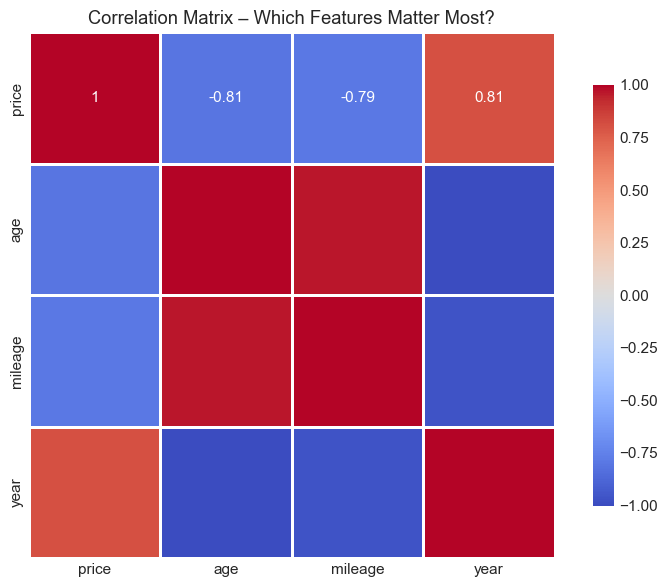


Key correlations with price:
Age: -0.809 (negative – expected)
Mileage: -0.790 (negative – expected)
Year: 0.809 (positive – newer is better)


In [48]:
# Cell 17: Correlation matrix for numeric features
numeric_cols = ['price', 'age', 'mileage', 'year']
corr_matrix = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
ax.set_title('Correlation Matrix – Which Features Matter Most?')

plt.tight_layout()
plt.show()

print("\nKey correlations with price:")
print(f"Age: {corr_matrix.loc['price', 'age']:.3f} (negative – expected)")
print(f"Mileage: {corr_matrix.loc['price', 'mileage']:.3f} (negative – expected)")
print(f"Year: {corr_matrix.loc['price', 'year']:.3f} (positive – newer is better)")

In [ ]:
## Red box= strong positive
## Blue box= strong negetive

## **Final Report**
1. Data Overview

The dataset contains information about cars, including price, age, mileage, and manufacturing year.
The data was cleaned by removing incorrect values and handling missing data.

2. Key Findings
Price and Age: There is a strong negative relationship. Older cars have lower prices.
Price and Mileage: Higher mileage leads to lower prices.
Price and Year: Newer cars have higher prices.

3. Important Patterns
Older cars usually have higher mileage.
Price is affected by multiple factors, not just one.
Age and mileage together play a major role in reducing car price.